<a href="https://colab.research.google.com/github/HamdiMohamedElKhames/RepGitSequence/blob/main/Energy-consumption-prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [49]:
!pip install kaggle seaborn scikit-learn

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [3]:
eenergetic=pd.read_csv('/content/drive/MyDrive/mini-projet-data-analyst/Energy_consumption.csv')
eenergetic.head()

,Timestamp,Temperature,Humidity,SquareFootage,Occupancy,HVACUsage,LightingUsage,RenewableEnergy,DayOfWeek,Holiday,EnergyConsumption
0,2022-01-01 00:00:00,25.139433,43.431581,1565.693999,5,On,Off,2.774699,Monday,No,75.364373
1,2022-01-01 01:00:00,27.731651,54.225919,1411.064918,1,On,On,21.831384,Saturday,No,83.401855
2,2022-01-01 02:00:00,28.704277,58.907658,1755.715009,2,Off,Off,6.764672,Sunday,No,78.270888
3,2022-01-01 03:00:00,20.080469,50.371637,1452.316318,1,Off,On,8.623447,Wednesday,No,56.519850
4,2022-01-01 04:00:00,23.097359,51.401421,1094.130359,9,On,Off,3.071969,Friday,No,70.811732


In [11]:
eenergetic.shape

(1000, 11)

In [12]:
eenergetic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Timestamp          1000 non-null   object 
 1   Temperature        1000 non-null   float64
 2   Humidity           1000 non-null   float64
 3   SquareFootage      1000 non-null   float64
 4   Occupancy          1000 non-null   int64  
 5   HVACUsage          1000 non-null   object 
 6   LightingUsage      1000 non-null   object 
 7   RenewableEnergy    1000 non-null   float64
 8   DayOfWeek          1000 non-null   object 
 9   Holiday            1000 non-null   object 
 10  EnergyConsumption  1000 non-null   float64
dtypes: float64(5), int64(1), object(5)
memory usage: 86.1+ KB


In [13]:
eenergetic.describe()

,Temperature,Humidity,SquareFootage,Occupancy,RenewableEnergy,EnergyConsumption
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,24.982026,45.395412,1500.052488,4.581000,15.132813,77.055873
std,2.836850,8.518905,288.418873,2.865598,8.745917,8.144112
min,20.007565,30.015975,1000.512661,0.000000,0.006642,53.263278
25%,22.645070,38.297722,1247.108548,2.000000,7.628385,71.544690
50%,24.751637,45.972116,1507.967426,5.000000,15.072296,76.943696
75%,27.418174,52.420066,1740.340165,7.000000,22.884064,82.921742
max,29.998671,59.969085,1999.982252,9.000000,29.965327,99.201120


In [9]:
eenergetic.columns

Index(['Timestamp', 'Temperature', 'Humidity', 'SquareFootage', 'Occupancy',
       'HVACUsage', 'LightingUsage', 'RenewableEnergy', 'DayOfWeek', 'Holiday',
       'EnergyConsumption'],
      dtype='object')

In [18]:
#missing values
eenergetic.isnull().sum()

,0
Timestamp,0
Temperature,0
Humidity,0
SquareFootage,0
Occupancy,0
HVACUsage,0
LightingUsage,0
RenewableEnergy,0
DayOfWeek,0
Holiday,0


In [15]:
#delete missing values
eenergetic = eenergetic.dropna()

In [19]:
#duplicated values
eenergetic.duplicated().sum()

np.int64(0)

In [20]:
#delete duplicated values
eenergetic = eenergetic.drop_duplicates()

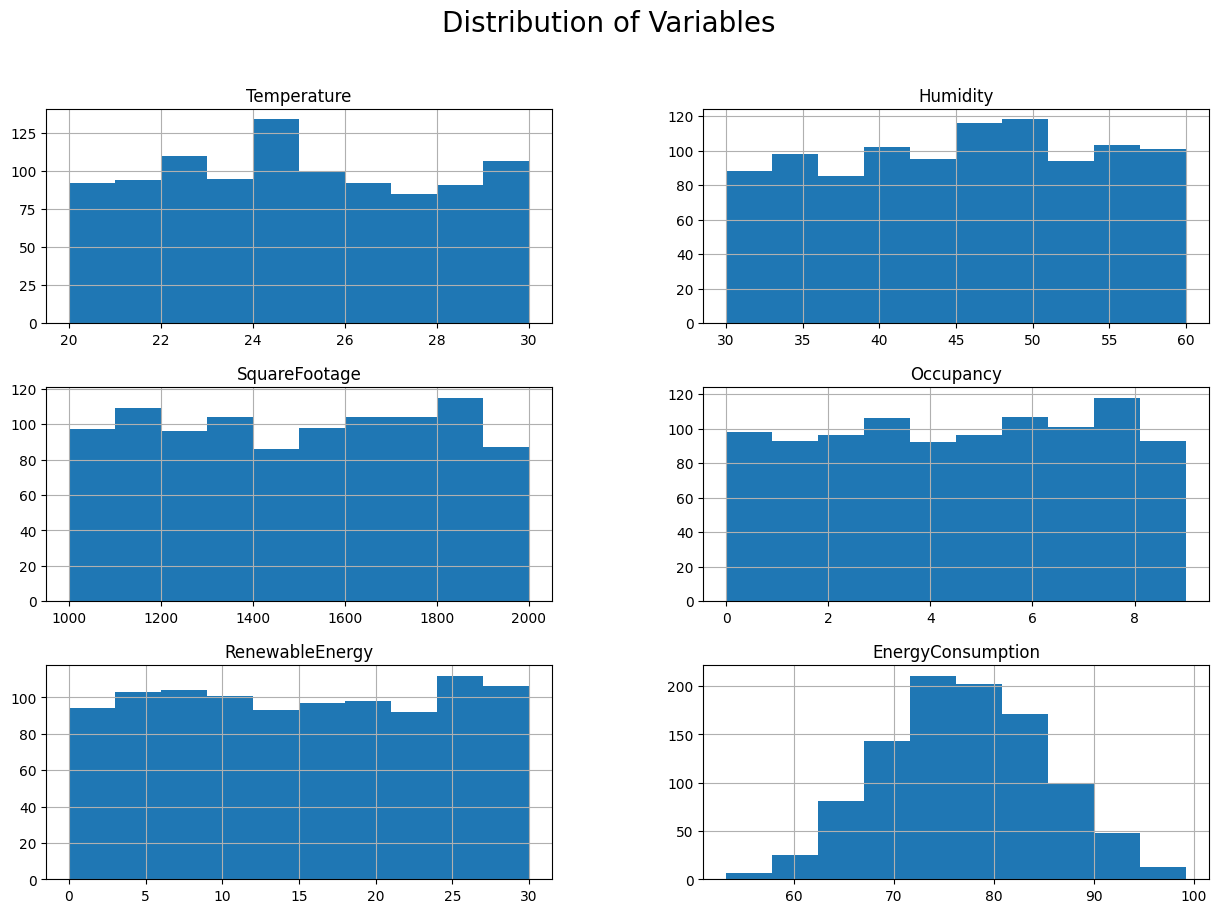

In [28]:
eenergetic.hist(figsize=(15,10))

plt.suptitle("Distribution of Variables", fontsize=20)

plt.show()

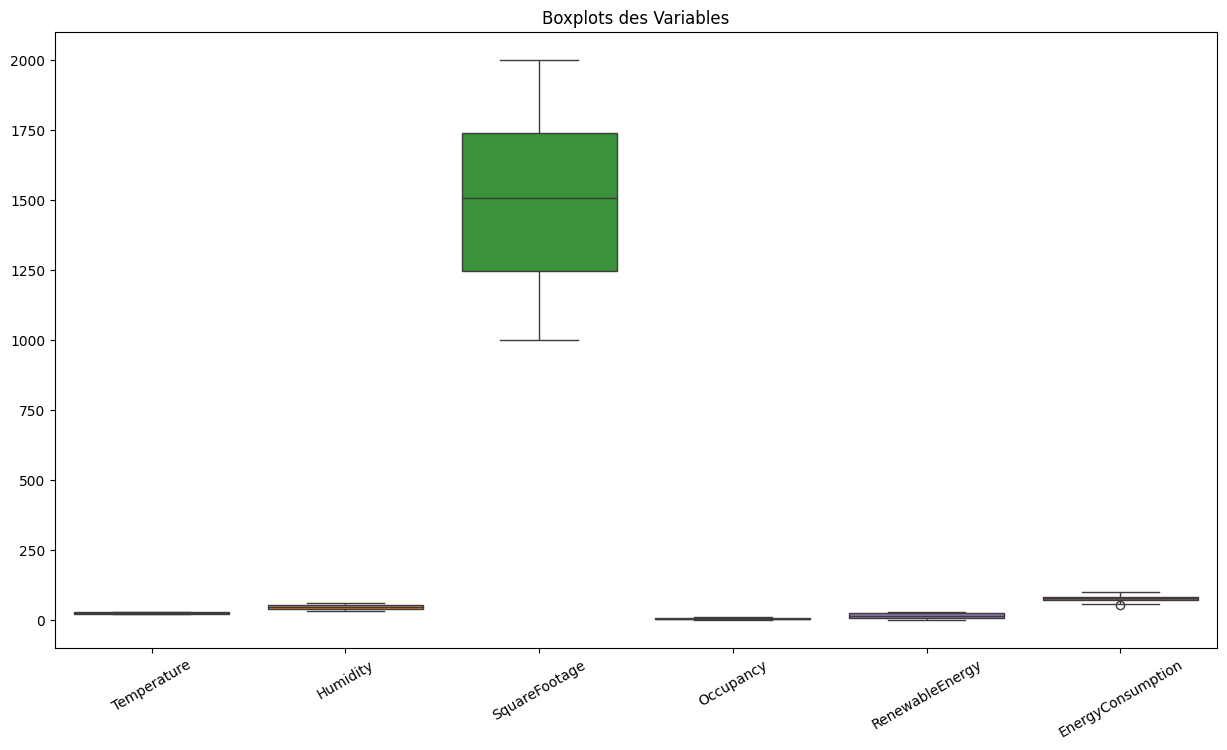

In [34]:
plt.figure(figsize=(15,8))

sns.boxplot(data=eenergetic)

plt.xticks(rotation=30)

plt.title("Boxplots des Variables")

plt.show()

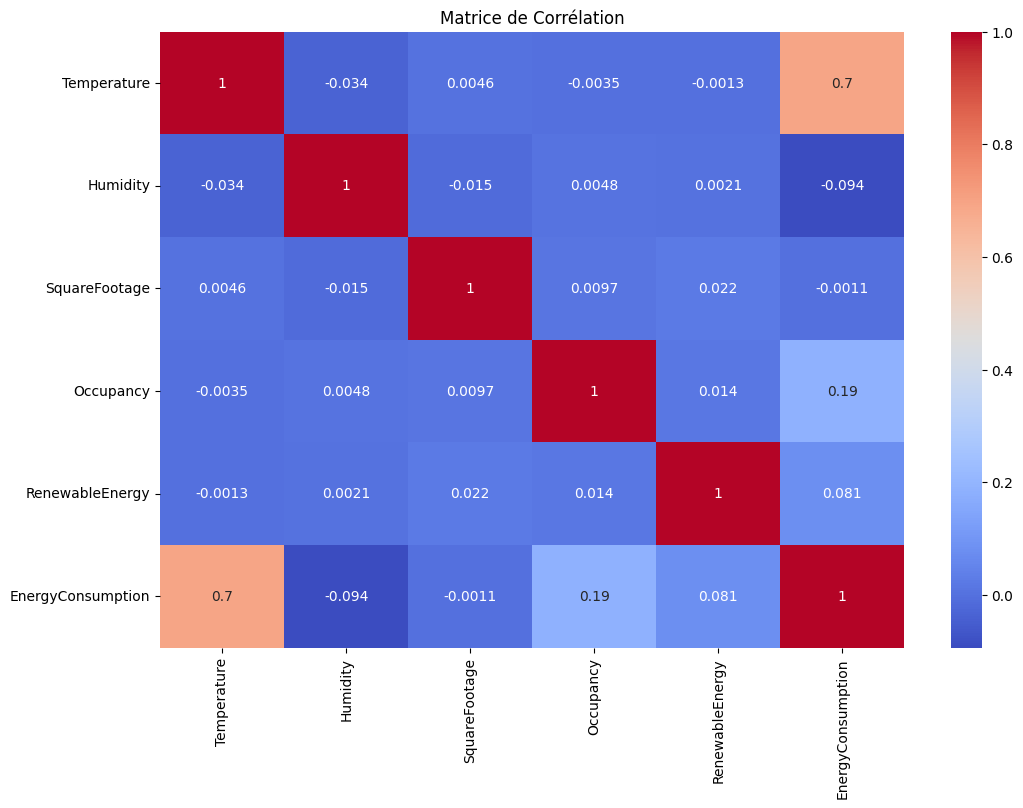

In [36]:
plt.figure(figsize=(12,8))

sns.heatmap(
    eenergetic.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Matrice de Corrélation")

plt.show()

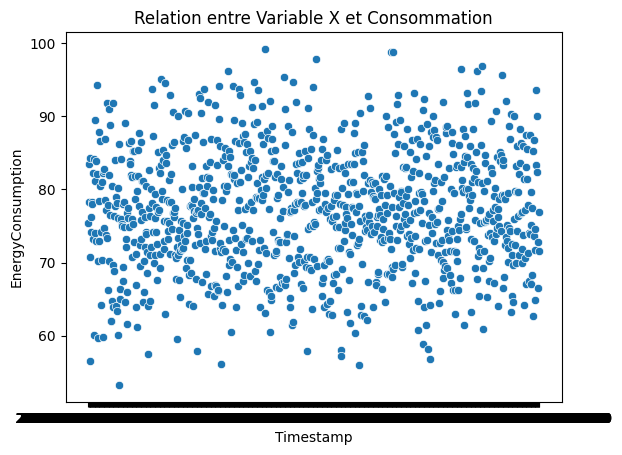

In [37]:
sns.scatterplot(
    x=eenergetic.iloc[:,0],
    y=eenergetic.iloc[:,-1]
)

plt.title("Relation entre Variable X et Consommation")

plt.show()

In [38]:
X = eenergetic.iloc[:, :-1]

y = eenergetic.iloc[:, -1]

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [41]:
scaler = StandardScaler()

# Convert 'Timestamp' column to datetime and extract numerical features
X_train['Timestamp'] = pd.to_datetime(X_train['Timestamp'])
X_test['Timestamp'] = pd.to_datetime(X_test['Timestamp'])

X_train['Hour'] = X_train['Timestamp'].dt.hour
X_train['DayOfMonth'] = X_train['Timestamp'].dt.day
X_train['Month'] = X_train['Timestamp'].dt.month
X_train['DayOfWeekNum'] = X_train['Timestamp'].dt.dayofweek

X_test['Hour'] = X_test['Timestamp'].dt.hour
X_test['DayOfMonth'] = X_test['Timestamp'].dt.day
X_test['Month'] = X_test['Timestamp'].dt.month
X_test['DayOfWeekNum'] = X_test['Timestamp'].dt.dayofweek

X_train = X_train.drop('Timestamp', axis=1)
X_test = X_test.drop('Timestamp', axis=1)

# Identify categorical columns for one-hot encoding
categorical_cols = ['HVACUsage', 'LightingUsage', 'DayOfWeek', 'Holiday']

# Apply one-hot encoding
X_train = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

# Align columns between X_train and X_test after one-hot encoding
# This handles cases where a category might be present in train but not test, or vice-versa
train_cols = X_train.columns
test_cols = X_test.columns

missing_in_test = set(train_cols) - set(test_cols)
for c in missing_in_test:
    X_test[c] = 0

missing_in_train = set(test_cols) - set(train_cols)
for c in missing_in_train:
    X_train[c] = 0

X_test = X_test[train_cols] # Ensure column order is the same

# Now apply the StandardScaler
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [43]:
model = LinearRegression()

In [44]:
model.fit(X_train, y_train)

LinearRegression()

In [45]:
y_pred = model.predict(X_test)

In [46]:
mae = mean_absolute_error(y_test, y_pred)

print("MAE :", mae)

MAE : 4.090794836849812


In [47]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("RMSE :", rmse)

RMSE : 5.160410593073975


In [51]:
r2 = r2_score(y_test, y_pred)

print("R2 Score :", r2)

R2 Score : 0.5934368230348608


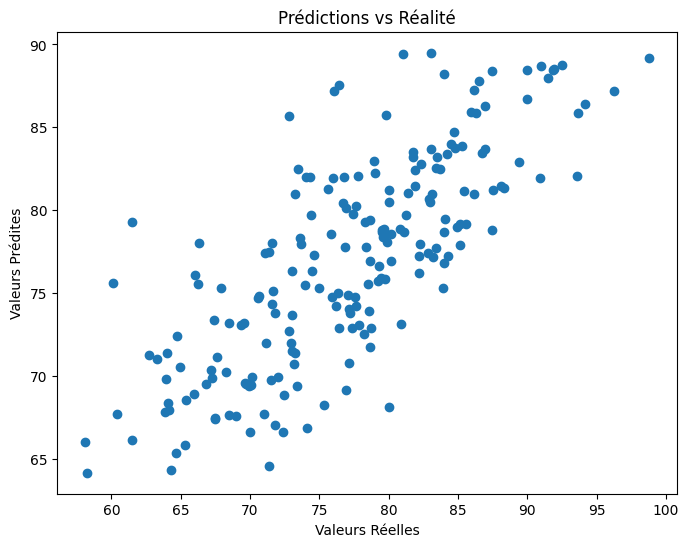

In [52]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Valeurs Réelles")

plt.ylabel("Valeurs Prédites")

plt.title("Prédictions vs Réalité")

plt.show()